In [95]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# pip install numpy pandas 
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# pip install kagglehub
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# pip install matplotlib
import matplotlib.pyplot as plt


In [96]:
train_data = pd.read_csv("train.csv")
train_data.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [97]:
train_data.shape # (Anzahl_Zeilen: 891, Anzahl_Spalten: 12)

(891, 12)

In [98]:
# Check column types
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [99]:
# Check missing values
train_data.isna().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [100]:
# Statistical summary of the dataset
train_data.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


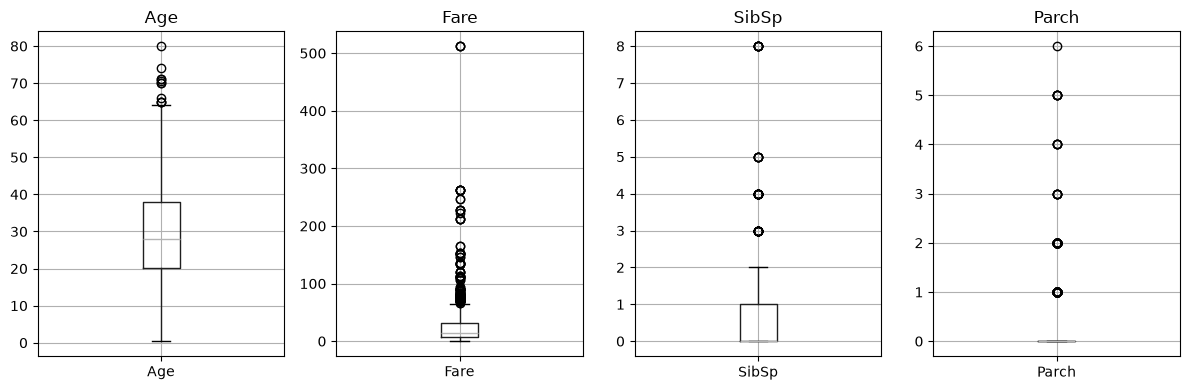

In [101]:
columns = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for ax, column in zip(axes, columns):
    train_data.boxplot(column=column, ax=ax)
    ax.set_title(column)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

- **Age:** Das mittlere Alter beträgt etwa **29,7 Jahre**, der Median **28 Jahre**; die mittleren 50 % liegen zwischen **20,1 und 38 Jahren**, während einzelne hohe Alterswerte im Boxplot als Ausreißer erscheinen.
- **Fare:** Der durchschnittliche Fahrpreis beträgt **32,20**, der Median jedoch nur **14,45**; die mittleren 50 % liegen zwischen **7,91 und 31,00**, und viele hohe Preise bis **512,33** machen die Verteilung stark rechtsschief.
- **SibSp:** Die meisten Passagiere hatten keine Geschwister oder Ehepartner an Bord; der Median ist **0**, die mittleren 50 % liegen zwischen **0 und 1**, und Werte ab **3** erscheinen als Ausreißer.
- **Parch:** Mindestens 75 % der Passagiere hatten keine Eltern oder Kinder an Bord; deshalb liegen Median und beide Quartile bei **0**, die Box fällt zusammen und alle positiven Werte bis **6** erscheinen als Ausreißer.

## Gesamtüberlebensrate

In [102]:
# Survival balance
survival_balance = pd.DataFrame({
    "passengers": train_data["Survived"].value_counts(),
    "survival_rate": train_data["Survived"]
        .value_counts(normalize=True).mul(100).round(1)
}).rename(index={0: "Nicht überlebt", 1: "Überlebt"})

survival_balance
# 61.6% of passengers did not survive
# 38.4% of passengers survived

,passengers,survival_rate
Survived,,
Nicht überlebt,549,61.6
Überlebt,342,38.4


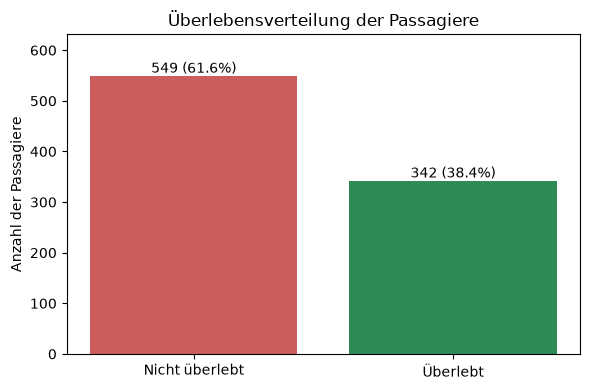

In [103]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    survival_balance.index,
    survival_balance["passengers"],
    color=["indianred", "seagreen"]
)

for bar, count, rate in zip(
    bars,
    survival_balance["passengers"],
    survival_balance["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count} ({rate:.1f}%)",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensverteilung der Passagiere")
ax.set_ylabel("Anzahl der Passagiere")
ax.set_ylim(0, survival_balance["passengers"].max() * 1.15)

plt.tight_layout()
plt.show()

## Überlebensrate nach Geschlecht

In [104]:
# Survival rate by gender
sex_survival = (
    train_data.groupby("Sex")["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

sex_survival["survival_rate"] = (
    sex_survival["survival_rate"] * 100
).round(1)

sex_survival
# 74.2% of females survived
# 18.9% of males survived

,passengers,survival_rate
Sex,,
female,314,74.2
male,577,18.9


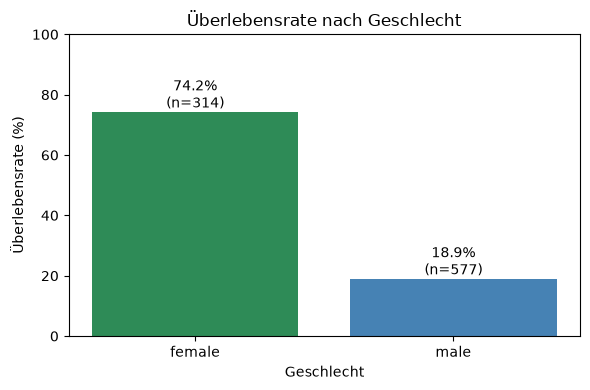

In [105]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    sex_survival.index,
    sex_survival["survival_rate"],
    color=["seagreen", "steelblue"]
)

for bar, count, rate in zip(
    bars,
    sex_survival["passengers"],
    sex_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Geschlecht")
ax.set_xlabel("Geschlecht")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Überlebensrate nach Klasse

In [106]:
# Survival rate by class
class_survival = (
    train_data.groupby("Pclass")["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

class_survival["survival_rate"] = (
    class_survival["survival_rate"] * 100
).round(1)

class_survival

,passengers,survival_rate
Pclass,,
1,216,63.0
2,184,47.3
3,491,24.2


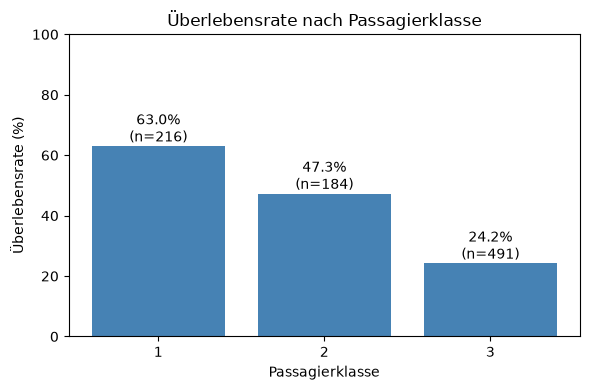

In [107]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    class_survival.index.astype(str),
    class_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    class_survival["passengers"],
    class_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Passagierklasse")
ax.set_xlabel("Passagierklasse")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Überlebensrate nach Altersgruppen

In [108]:
# Survival rate by age group
train_data['AgeGroup'] = pd.cut(train_data['Age'], bins=[0, 12, 18, 35, 60, 80], labels=['Child', 'Teenager', 'Adult', 'Middle-aged', 'Senior'])
train_data["AgeGroup"] = train_data["AgeGroup"].cat.add_categories("Unknown").fillna("Unknown")

age_survival = (
    train_data.groupby("AgeGroup", observed=True)["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

age_survival["survival_rate"] = (
    age_survival["survival_rate"] * 100
).round(1)

age_survival
# 58.0% of children survived <-- höchste Überlebensrate
# 42.9% of teenagers survived
# 38.3% of adults survived
# 40.0% of middle-aged survived
# 22.7% of seniors survived <-- niedrigste Überlebensrate
# 29.4% of unknown age survived

,passengers,survival_rate
AgeGroup,,
Child,69,58.0
Teenager,70,42.9
Adult,358,38.3
Middle-aged,195,40.0
Senior,22,22.7
Unknown,177,29.4


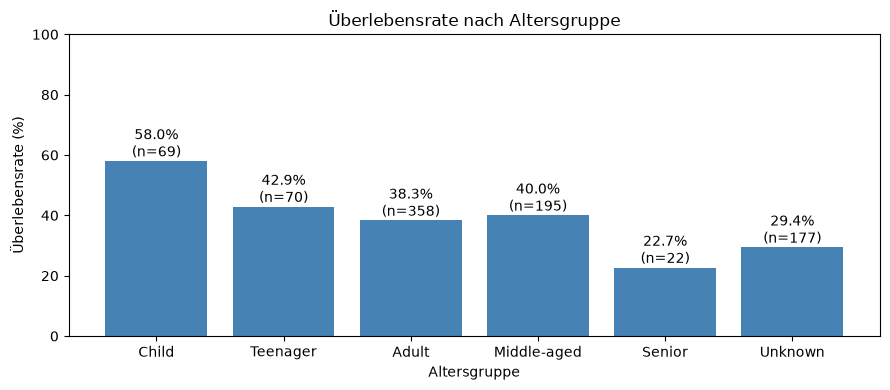

In [109]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(
    age_survival.index.astype(str),
    age_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    age_survival["passengers"],
    age_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Altersgruppe")
ax.set_xlabel("Altersgruppe")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Überlebensrate nach Title

In [110]:
# Survival rate by title
train_data["Title"] = train_data["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()

title_survival = (
    train_data.groupby("Title")
    .agg(
        passengers=("Survived", "count"),
        survival_rate=("Survived", "mean")
    )
    .sort_values("passengers", ascending=False)
)

title_survival["survival_rate"] = (title_survival["survival_rate"] * 100).round(1)
title_survival # Mrs, Miss, Master, Mr and Others

,passengers,survival_rate
Title,,
Mr,517,15.7
Miss,182,69.8
Mrs,125,79.2
Master,40,57.5
Dr,7,42.9
Rev,6,0.0
Mlle,2,100.0
Major,2,50.0
Col,2,50.0


In [111]:
main_titles = ["Mrs", "Miss", "Master", "Mr"]
train_data["TitleGroup"] = train_data["Title"].where(train_data["Title"].isin(main_titles), "Rare Titles")

title_survival = train_data.groupby("TitleGroup").agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

title_survival["survival_rate"] = title_survival["survival_rate"].mul(100).round(1)
title_survival = title_survival.sort_values(by="survival_rate", ascending=False)

title_survival
# 79,2% of Mrs survived <-- höchste Überlebensrate (verheiratete Frauen)
# 69.8% of Miss survived
# 57.5% of Master survived
# 44.4% of Rare Titles survived
# 15.7% of Mr survived <-- niedrigste Überlebensrate (Vgl.: 18.9% of males survived)

,passengers,survival_rate
TitleGroup,,
Mrs,125,79.2
Miss,182,69.8
Master,40,57.5
Rare Titles,27,44.4
Mr,517,15.7


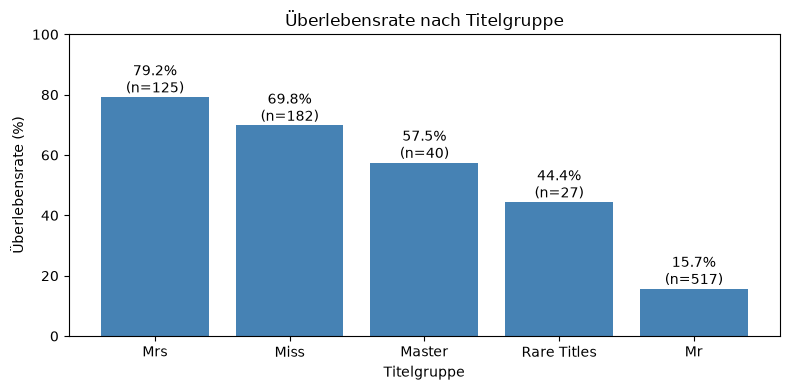

In [112]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    title_survival.index,
    title_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    title_survival["passengers"],
    title_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Titelgruppe")
ax.set_xlabel("Titelgruppe")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Überlebensrate nach Ticketpreis

In [113]:
# Survival rate by fare
train_data["FareGroup"] = pd.cut(
    train_data["Fare"],
    bins=[-float("inf"), 40, 80, float("inf")],
    labels=["0-40", "40-80", ">80"]
)

fare_survival = (
    train_data.groupby("FareGroup", observed=True)["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

fare_survival["survival_rate"] = (
    fare_survival["survival_rate"] * 100
).round(1)

fare_survival
# 77% of passengers with fare >80 survived <-- höchste Überlebensrate
# 54.9% of passengers with fare 40-80 survived
# 32% of passengers with fare 0-40 survived

,passengers,survival_rate
FareGroup,,
0-40,715,32.0
40-80,102,54.9
>80,74,77.0


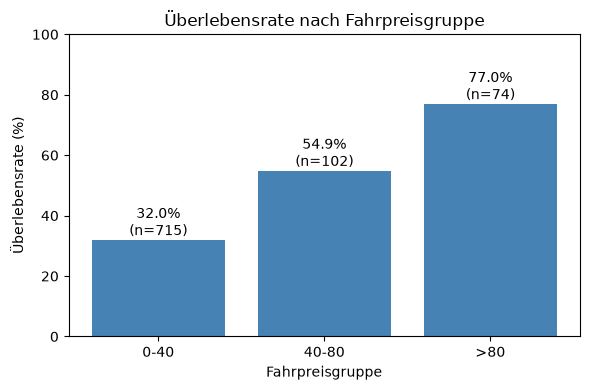

In [114]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    fare_survival.index.astype(str),
    fare_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    fare_survival["passengers"],
    fare_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Fahrpreisgruppe")
ax.set_xlabel("Fahrpreisgruppe")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Überlebensrate nach Familiengröße

In [115]:
# Anzahl an Passagieren mit/ohne Eltern/Kindern an Bord
train_data["Parch"].value_counts().sort_index()
##   0: 678
##   1: 118
## > 1: 95

Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64

In [116]:
# Familiengröße inklusive der Person selbst
train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"] + 1

In [117]:
train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"] + 1

train_data["FamilySizeGroup"] = pd.cut(
    train_data["FamilySize"],
    bins=[0, 1, 2, 3, 4, 5, float("inf")],
    labels=["1", "2", "3", "4", "5", ">5"]
)

family_survival = (
    train_data.groupby("FamilySizeGroup", observed=True)["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

family_survival["survival_rate"] = (
    family_survival["survival_rate"] * 100
).round(1)

family_survival
# 4: 72.4 % <-- höchste Überlebensrate (nur 29 Passagiere)
# > 5; 14.9% <-- niedrigste Überlebensrate (nur 47 Passagiere)

,passengers,survival_rate
FamilySizeGroup,,
1,537,30.4
2,161,55.3
3,102,57.8
4,29,72.4
5,15,20.0
>5,47,14.9


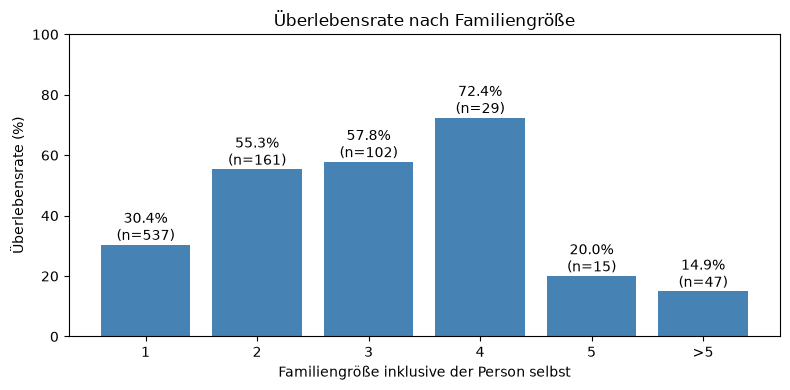

In [118]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    family_survival.index.astype(str),
    family_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    family_survival["passengers"],
    family_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Familiengröße")
ax.set_xlabel("Familiengröße inklusive der Person selbst")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Erste Zsfg.

- Geschlecht, Titel, Fare zeigen Überlebensraten > 75 %
- Frauen ~74%
- verheiratete Frauen ~79%
- Rich folks (Fare>80) ~77%
- 1st Class ~63%
- Männer ~18%
- Mr ~15%
- große Familien (5 und >5) ~20% und ~15%



## Geschlecht und Klasse

In [119]:
sex_class_survival = train_data.groupby(["Sex", "Pclass"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

sex_class_survival["survival_rate"] = (
    sex_class_survival["survival_rate"].mul(100).round(1)
)

sex_class_survival

passengers  survival_rate
Sex    Pclass                           
female 1               94           96.8
       2               76           92.1
       3              144           50.0
male   1              122           36.9
       2              108           15.7
       3              347           13.5

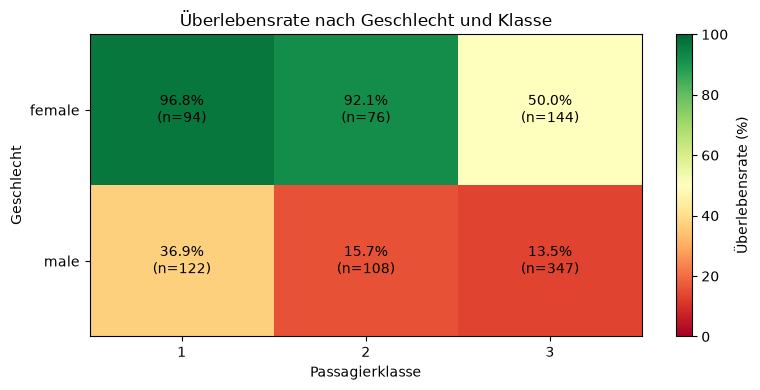

In [120]:
rates = sex_class_survival["survival_rate"].unstack("Pclass")
counts = sex_class_survival["passengers"].unstack("Pclass")

fig, ax = plt.subplots(figsize=(8, 4))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Passagierklasse")
ax.set_ylabel("Geschlecht")
ax.set_title("Überlebensrate nach Geschlecht und Klasse")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()

## Titel und Klasse

In [121]:
title_class_survival = train_data.groupby(["TitleGroup", "Pclass"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

title_class_survival["survival_rate"] = (
    title_class_survival["survival_rate"].mul(100).round(1)
)

title_class_survival

passengers  survival_rate
TitleGroup  Pclass                           
Master      1                3          100.0
            2                9          100.0
            3               28           39.3
Miss        1               46           95.7
            2               34           94.1
            3              102           50.0
Mr          1              107           34.6
            2               91            8.8
            3              319           11.3
Mrs         1               42           97.6
            2               41           90.2
            3               42           50.0
Rare Titles 1               18           61.1
            2                9           11.1

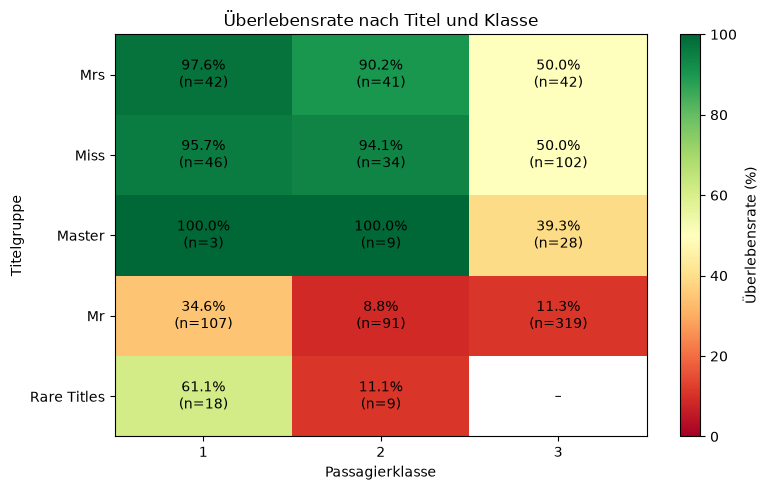

In [122]:
title_order = ["Mrs", "Miss", "Master", "Mr", "Rare Titles"]

rates = title_class_survival["survival_rate"].unstack("Pclass").reindex(title_order)
counts = title_class_survival["passengers"].unstack("Pclass").reindex(title_order)

fig, ax = plt.subplots(figsize=(8, 5))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Passagierklasse")
ax.set_ylabel("Titelgruppe")
ax.set_title("Überlebensrate nach Titel und Klasse")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()

## Geschlecht und Ticketpreis

In [123]:
sex_faregroup_survival = train_data.groupby(["Sex", "FareGroup"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

sex_faregroup_survival["survival_rate"] = (
    sex_faregroup_survival["survival_rate"].mul(100).round(1)
)

sex_faregroup_survival

passengers  survival_rate
Sex    FareGroup                           
female 0-40              221           66.5
       40-80              45           88.9
       >80                48           95.8
male   0-40              494           16.6
       40-80              57           28.1
       >80                26           42.3

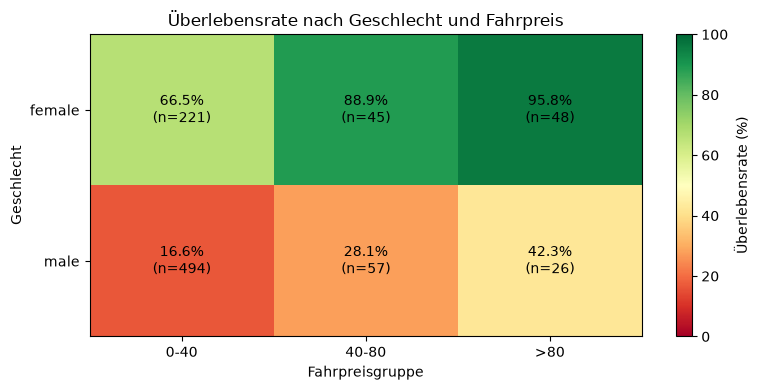

In [124]:
rates = sex_faregroup_survival["survival_rate"].unstack("FareGroup")
counts = sex_faregroup_survival["passengers"].unstack("FareGroup")

fig, ax = plt.subplots(figsize=(8, 4))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Fahrpreisgruppe")
ax.set_ylabel("Geschlecht")
ax.set_title("Überlebensrate nach Geschlecht und Fahrpreis")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()

## Klasse und Ticketpreis

In [125]:
class_faregroup_survival = train_data.groupby(["Pclass", "FareGroup"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

class_faregroup_survival["survival_rate"] = (
    class_faregroup_survival["survival_rate"].mul(100).round(1)
)

class_faregroup_survival

passengers  survival_rate
Pclass FareGroup                           
1      0-40               70           45.7
       40-80              72           65.3
       >80                74           77.0
2      0-40              174           47.7
       40-80              10           40.0
3      0-40              471           24.2
       40-80              20           25.0

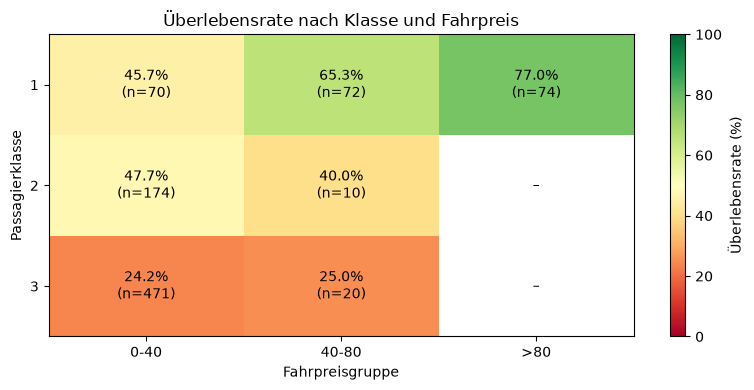

In [126]:
rates = class_faregroup_survival["survival_rate"].unstack("FareGroup")
counts = class_faregroup_survival["passengers"].unstack("FareGroup")

fig, ax = plt.subplots(figsize=(8, 4))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Fahrpreisgruppe")
ax.set_ylabel("Passagierklasse")
ax.set_title("Überlebensrate nach Klasse und Fahrpreis")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()

## Klasse und Familiengröße

In [127]:
class_family_survival = train_data.groupby(["Pclass", "FamilySizeGroup"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

class_family_survival["survival_rate"] = (
    class_family_survival["survival_rate"].mul(100).round(1)
)

class_family_survival

passengers  survival_rate
Pclass FamilySizeGroup                           
1      1                       109           53.2
       2                        70           72.9
       3                        24           75.0
       4                         7           71.4
       5                         2          100.0
       >5                        4           50.0
2      1                       104           34.6
       2                        34           52.9
       3                        31           67.7
       4                        13           76.9
       5                         1          100.0
       >5                        1          100.0
3      1                       324           21.3
       2                        57           35.1
       3                        47           42.6
       4                         9           66.7
       5                        12            0.0
       >5                       42            9.5

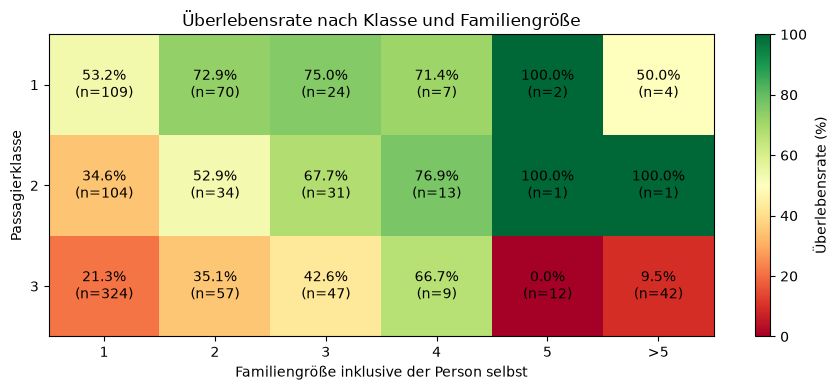

In [128]:
rates = class_family_survival["survival_rate"].unstack("FamilySizeGroup")
counts = class_family_survival["passengers"].unstack("FamilySizeGroup")

fig, ax = plt.subplots(figsize=(9, 4))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Familiengröße inklusive der Person selbst")
ax.set_ylabel("Passagierklasse")
ax.set_title("Überlebensrate nach Klasse und Familiengröße")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()

## Korrelation numerischer Features
- PassengerID können wir weglassen
- Geschlecht numerisch kodieren
- Pearson-Korrelation misst, wie stark zwei numerische Merkmale linear zusammenhängen
    - reagiert empfindlich auf Ausreißer
    - erkennt nicht-lineare Zusammenhänge schlecht

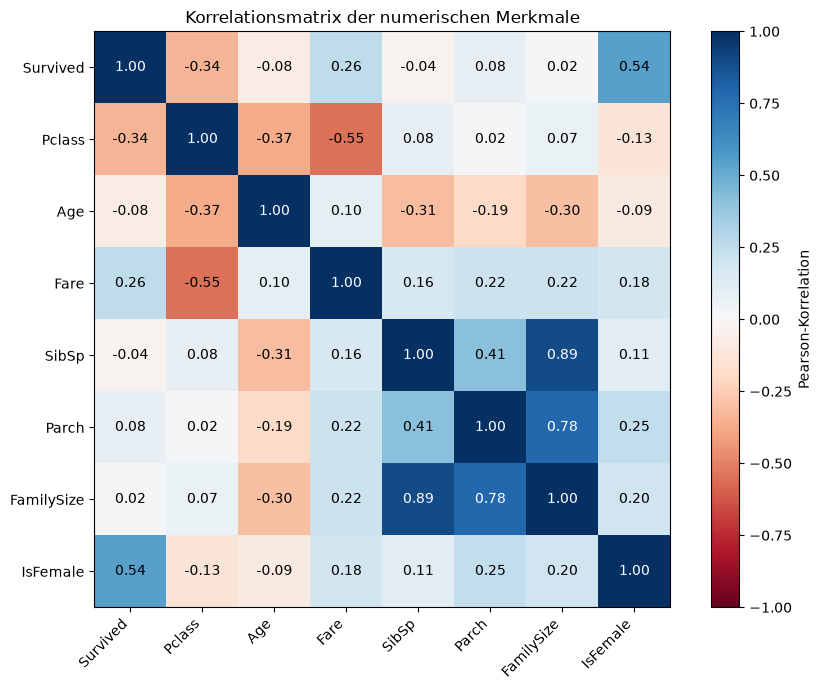

In [129]:
corr_data = train_data[
    ["Survived", "Pclass", "Age", "Fare", "SibSp", "Parch", "FamilySize"]
].copy()

corr_data["IsFemale"] = train_data["Sex"].map({"female": 1, "male": 0})
correlations = corr_data.corr()

fig, ax = plt.subplots(figsize=(9, 7))
heatmap = ax.imshow(correlations, cmap="RdBu", vmin=-1, vmax=1)

ax.set_xticks(
    range(len(correlations.columns)),
    labels=correlations.columns,
    rotation=45,
    ha="right"
)
ax.set_yticks(range(len(correlations.index)), labels=correlations.index)

for row in range(len(correlations.index)):
    for col in range(len(correlations.columns)):
        value = correlations.iloc[row, col]
        ax.text(
            col, row, f"{value:.2f}",
            ha="center", va="center",
            color="white" if abs(value) > 0.6 else "black"
        )

ax.set_title("Korrelationsmatrix der numerischen Merkmale")
fig.colorbar(heatmap, ax=ax, label="Pearson-Korrelation")
plt.tight_layout()
plt.show()

- IsFemale, Pclass und Fare mit den höchsten Korrelationswerten zu Survived
- Pclass-Fare: Passagiere mit höherer Klassennummer zahlten tendenziell weniger
- Pclass-Age: Passagiere mit höherer Klassennummer waren tendenziell jünger
- FamilySize berechnet sich aus SibSp und Parch, daher erwartbar höhere Werte

In [130]:
## Logistische Regression

## Support Vector Machine (linear)

Die lineare SVM lernt auf den Trainingsdaten eine gerade Trennfläche im mehrdimensionalen Merkmalsraum. 
Sie versucht, zwischen den beiden Gruppen einen möglichst breiten Abstand, die Trennmarge, zu schaffen. 
Besonders entscheidend sind die Support-Vektoren (Personen im Trainingsdatensatz, die an der Grenze liegen oder die Marge verletzen).

In [131]:
# pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score

# Merkmale und Zielvariable
data = train_data.copy()
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1

numeric_features = ["Age", "Fare", "FamilySize"]
categorical_features = ["Sex", "Pclass", "Embarked"]

X = data[numeric_features + categorical_features]
y = data["Survived"]

# 80 % Training, 20 % Validierung (179 Passagiere, davon 110 Nichtüberlebende und 69 Überlebende)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [132]:
# Fehlende Werte ersetzen und numerische Merkmale skalieren
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Fehlende Kategorien ersetzen und Kategorien codieren
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


In [133]:
preprocessing = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [134]:
# Lineare SVM
svm_model = Pipeline([
    ("preprocessing", preprocessing),
    ("svm", SVC(kernel="linear", C=1))
])

svm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Age','Fare','FamilySize','Sex','Pclass','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining

C bestimmt, wie stark die SVM Trainingsfehler bestraft:
- Kleines C: erlaubt mehr Fehler und bevorzugt eine größere Trennmarge. Mehr Trainingsfehler werden zugelassen.
- Großes C: versucht stärker, Trainingsfehler zu vermeiden; kann Overfitting begünstigen.

                precision    recall  f1-score   support

Nicht überlebt       0.80      0.85      0.82       110
      Überlebt       0.74      0.65      0.69        69

      accuracy                           0.78       179
     macro avg       0.77      0.75      0.76       179
  weighted avg       0.77      0.78      0.77       179

ROC-AUC: 0.806


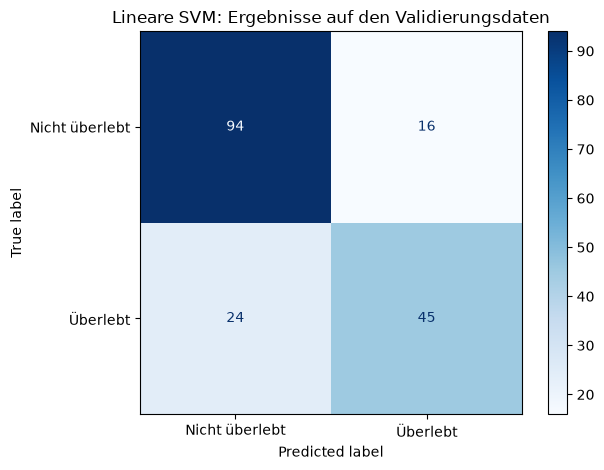

In [135]:
# Bewertung auf den Validierungsdaten
predictions = svm_model.predict(X_val)
scores = svm_model.decision_function(X_val)

print(classification_report(
    y_val,
    predictions,
    target_names=["Nicht überlebt", "Überlebt"],
    zero_division=0
))
print("ROC-AUC:", round(roc_auc_score(y_val, scores), 3))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    predictions,
    display_labels=["Nicht überlebt", "Überlebt"],
    cmap="Blues"
)
plt.title("Lineare SVM: Ergebnisse auf den Validierungsdaten")
plt.tight_layout()
plt.show()

Mit 0.85 im Recall bei den Nicht-Überlebenden sagt das Modell diese Gruppe zuverlässiger voraus, als mit 0.65 in der Überlebenden-Gruppe.

                precision    recall  f1-score   support

Nicht überlebt       0.80      0.85      0.83       110
      Überlebt       0.74      0.67      0.70        69

      accuracy                           0.78       179
     macro avg       0.77      0.76      0.77       179
  weighted avg       0.78      0.78      0.78       179

ROC-AUC: 0.836


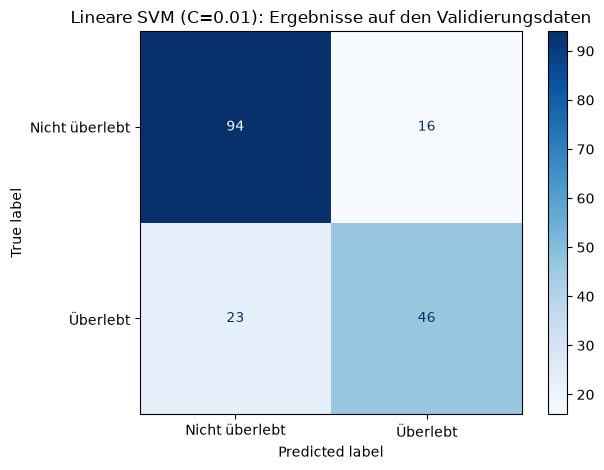

In [136]:
## C 0.01
# Lineare SVM
svm_model_C0_01 = Pipeline([
    ("preprocessing", preprocessing),
    ("svm", SVC(kernel="linear", C=0.01))
])

svm_model_C0_01.fit(X_train, y_train)

# Bewertung auf den Validierungsdaten
predictions = svm_model_C0_01.predict(X_val)
scores = svm_model_C0_01.decision_function(X_val)

print(classification_report(
    y_val,
    predictions,
    target_names=["Nicht überlebt", "Überlebt"],
    zero_division=0
))
print("ROC-AUC:", round(roc_auc_score(y_val, scores), 3))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    predictions,
    display_labels=["Nicht überlebt", "Überlebt"],
    cmap="Blues"
)
plt.title("Lineare SVM (C=0.01): Ergebnisse auf den Validierungsdaten")
plt.tight_layout()
plt.show()

                precision    recall  f1-score   support

Nicht überlebt       0.80      0.85      0.82       110
      Überlebt       0.74      0.65      0.69        69

      accuracy                           0.78       179
     macro avg       0.77      0.75      0.76       179
  weighted avg       0.77      0.78      0.77       179

ROC-AUC: 0.796


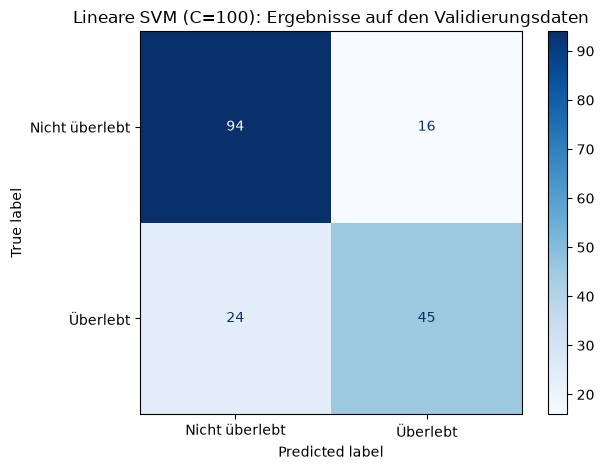

In [137]:
## C 100
# Lineare SVM
svm_model_C100 = Pipeline([
    ("preprocessing", preprocessing),
    ("svm", SVC(kernel="linear", C=100))
])

svm_model_C100.fit(X_train, y_train)

# Bewertung auf den Validierungsdaten
predictions = svm_model_C100.predict(X_val)
scores = svm_model_C100.decision_function(X_val)

print(classification_report(
    y_val,
    predictions,
    target_names=["Nicht überlebt", "Überlebt"],
    zero_division=0
))
print("ROC-AUC:", round(roc_auc_score(y_val, scores), 3))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    predictions,
    display_labels=["Nicht überlebt", "Überlebt"],
    cmap="Blues"
)
plt.title("Lineare SVM (C=100): Ergebnisse auf den Validierungsdaten")
plt.tight_layout()
plt.show()

## SVM mit RBF-Kernel

                precision    recall  f1-score   support

Nicht überlebt       0.80      0.94      0.86       110
      Überlebt       0.86      0.62      0.72        69

      accuracy                           0.82       179
     macro avg       0.83      0.78      0.79       179
  weighted avg       0.82      0.82      0.81       179

ROC-AUC: 0.836


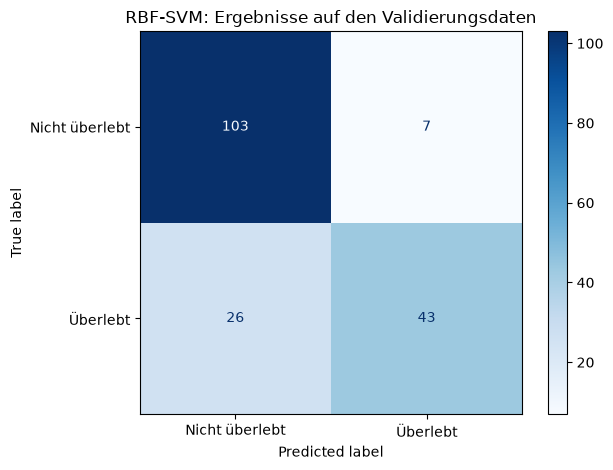

In [139]:
from sklearn.base import clone

# Vorverarbeitung übernehmen und eine neue SVM trainieren
rbf_model = clone(svm_model).set_params(
    svm__kernel="rbf",
    svm__C=1,
    svm__gamma="scale"
)

rbf_model.fit(X_train, y_train)

# Bewertung auf derselben Datenaufteilung
rbf_predictions = rbf_model.predict(X_val)
rbf_scores = rbf_model.decision_function(X_val)

print(classification_report(
    y_val,
    rbf_predictions,
    target_names=["Nicht überlebt", "Überlebt"],
    zero_division=0
))
print("ROC-AUC:", round(roc_auc_score(y_val, rbf_scores), 3))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    rbf_predictions,
    display_labels=["Nicht überlebt", "Überlebt"],
    cmap="Blues"
)
plt.title("RBF-SVM: Ergebnisse auf den Validierungsdaten")
plt.tight_layout()
plt.show()

### Zsfg. Vorgehen bei der SVM
Ziel ist es, anhand der Passagiermerkmale vorherzusagen, ob eine Person das Titanic-Unglück überlebt. Als Eingangsmerkmale verwenden wir Alter, Fahrpreis, Familiengröße, Geschlecht, Passagierklasse und Einstiegshafen (kann evtl. entfernt werden - wurde in der EDA nicht näher betrachtet). Die Familiengröße berechnen wir aus der Anzahl der Geschwister beziehungsweise Ehepartner und Eltern beziehungsweise Kinder an Bord, einschließlich der Person selbst.

Wir teilen die 891 Datensätze mit bekannten Überlebensinformationen in 80 % Trainingsdaten und 20 % Validierungsdaten auf. Die Aufteilung erfolgt reproduzierbar mit random_state=42 und unter Beibehaltung der Klassenanteile.

Die Vorverarbeitung wird gemeinsam mit der SVM in einer Pipeline umgesetzt. Fehlende numerische Werte ersetzen wir durch den Median, fehlende kategoriale Werte durch die häufigste Kategorie. Numerische Merkmale werden standardisiert und kategoriale Merkmale mittels One-Hot-Encoding codiert. Sämtliche Vorverarbeitungsschritte werden ausschließlich anhand der Trainingsdaten gelernt.